<a href="https://colab.research.google.com/github/riteshyadav-345/AmazonClone/blob/main/EndtoEnd_Placement_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('/content/drive/MyDrive/Placement.csv')

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [24]:
df.shape

(100, 4)

In [25]:
df .head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [26]:
df= df.iloc[:,1:]

In [27]:
 df.head()

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


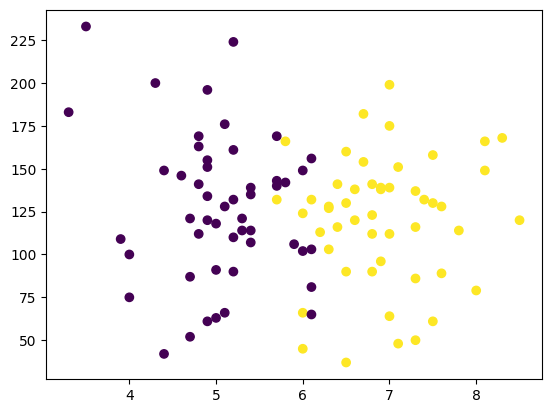

In [28]:
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])

In [29]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [30]:
X  #input

,CGPA,IQ
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [31]:
y   #output

,Placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [32]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1)

In [33]:
X_train

,CGPA,IQ
5,7.1,48
30,7.6,128
35,6.8,90
16,5.2,224
66,6.9,96
...,...,...
98,6.3,103
83,7.5,130
4,5.8,142
96,4.4,42


In [34]:
y_train

,Placement
5,1
30,1
35,1
16,0
66,1
...,...
98,1
83,1
4,0
96,0


In [35]:
X_test

,CGPA,IQ
79,6.5,90
31,3.9,109
57,6.5,130
94,4.7,52
12,5.4,139
56,6.1,65
53,8.3,168
62,6.0,102
50,3.5,233
80,4.9,196


In [36]:
y_test

,Placement
79,1
31,0
57,1
94,0
12,0
56,0
53,1
62,0
50,0
80,0


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [38]:
X_train = scaler.fit_transform(X_train)

In [39]:
X_train

array([[ 9.63359413e-01, -1.98912533e+00],
       [ 1.41634973e+00,  1.31351776e-01],
       [ 6.91565222e-01, -8.75874849e-01],
       [-7.58003802e-01,  2.67592430e+00],
       [ 7.82163286e-01, -7.16839066e-01],
       [ 1.32575167e+00, -1.64454780e+00],
       [-1.84518057e+00, -6.10815211e-01],
       [ 1.47976838e-01, -2.66237681e-01],
       [-6.67405738e-01, -5.41899705e-02],
       [ 6.91565222e-01, -2.92743645e-01],
       [-1.12039606e+00, -2.92743645e-01],
       [ 1.86934005e+00,  1.13857840e+00],
       [-1.12039606e+00,  4.75929306e-01],
       [ 5.73787738e-02,  2.37375632e-01],
       [-2.47936702e+00,  1.58917979e+00],
       [ 6.91565222e-01,  4.75929306e-01],
       [-1.23817354e-01, -4.51779428e-01],
       [ 3.29172966e-01,  4.75929306e-01],
       [-7.58003802e-01,  1.00604858e+00],
       [-3.05013482e-01,  5.28941234e-01],
       [-5.76807674e-01, -4.25273464e-01],
       [ 8.72761349e-01,  1.37713208e+00],
       [ 8.72761349e-01, -2.92743645e-01],
       [ 1.

In [40]:
X_test = scaler.transform(X_test)


In [41]:
X_test

array([[ 0.41977103, -0.87587485],
       [-1.93577863, -0.37226154],
       [ 0.41977103,  0.1843637 ],
       [-1.21099412, -1.88310147],
       [-0.57680767,  0.42291738],
       [ 0.05737877, -1.53852394],
       [ 2.05053618,  1.19159033],
       [-0.03321929, -0.55780328],
       [-2.29817089,  2.91447798],
       [-1.02979799,  1.93375732]])

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
clf = LogisticRegression()

In [44]:
clf.fit(X_train,y_train)    #Model Training

LogisticRegression()

In [45]:
y_pred = clf.predict(X_test)

In [46]:
y_test

,Placement
79,1
31,0
57,1
94,0
12,0
56,0
53,1
62,0
50,0
80,0


In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_test,y_pred)

0.8

In [49]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

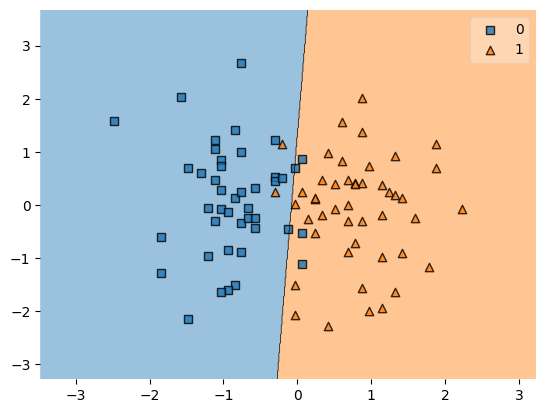

In [50]:
plot_decision_regions(X_train,y_train.values,clf=clf)
#

In [51]:
import pickle   #python ke object ko file me convert kar deta hai
                 #model ko transport karne ke liye


In [52]:
pickle.dump(clf,open('model.pkl','wb'))